<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/03_montecarlo_dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Monte Carlo Dropout

## What This Notebook Covers
Standard dropout is a **training-time regularizer** — it is switched off at inference.
**Monte Carlo (MC) Dropout** flips that: we keep dropout ON during prediction and run
the same input through the network N times. The spread of those N predictions becomes
an **uncertainty estimate**.

- High agreement across runs → model is **confident**
- High spread across runs → model is **uncertain**

This gives us a cheap Bayesian approximation without changing the architecture at all.

**Use cases:** medical diagnosis, autonomous driving, fraud detection — anywhere you
need to know *how much to trust* a prediction, not just what the prediction is.

**Both TensorFlow and PyTorch implementations are shown.**

**Dataset:** Fashion-MNIST


## Part A — TensorFlow / Keras Implementation


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


### 1. Load Data


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0

X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]

CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (55000, 28, 28), Valid: (5000, 28, 28), Test: (10000, 28, 28)


### 2. Build & Train a Model WITH Dropout

The model architecture is identical to Notebook 01. The key difference is that we
will call it with `training=True` at inference time to keep dropout active.


In [10]:
def build_dropout_model(dropout_rate=0.3):
    """Standard model with Dropout layers — same as Notebook 01."""
    return tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)), # Explicitly define input shape
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(300, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(200, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate * 0.7),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])

tf_model = build_dropout_model(dropout_rate=0.3)
tf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Training model...')
history = tf_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=20,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

std_loss, std_acc = tf_model.evaluate(X_test, y_test, verbose=0)
print(f'\nStandard (dropout OFF) test accuracy: {std_acc:.4f}')

Training model...
Epoch 1/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7726 - loss: 0.6306 - val_accuracy: 0.8588 - val_loss: 0.3982
Epoch 2/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8378 - loss: 0.4495 - val_accuracy: 0.8676 - val_loss: 0.3636
Epoch 3/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8518 - loss: 0.4102 - val_accuracy: 0.8756 - val_loss: 0.3413
Epoch 4/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8617 - loss: 0.3840 - val_accuracy: 0.8782 - val_loss: 0.3325
Epoch 5/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8667 - loss: 0.3668 - val_accuracy: 0.8820 - val_loss: 0.3174
Epoch 6/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8712 - loss: 0.3537 - val_accuracy: 0.8804 - val_loss: 0.3179
Epoch 7/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8714 - loss: 0.3484 - val_accuracy: 0.8890 - val_loss: 0.3016
Epoch 8/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8772 - loss: 0.3335

### 3. MC Dropout Inference — The Core Idea

The entire trick is one argument: `training=True` inside the prediction call.
This tells Keras to keep dropout active even though we are not in a training loop.
We run N stochastic forward passes and collect the distribution of outputs.

```
predictions shape: (N_samples, batch_size, n_classes)
mean across axis=0  → final prediction
std  across axis=0  → uncertainty estimate
```


In [5]:
def mc_dropout_predict(model, X, n_samples=100):
    """
    Run N stochastic forward passes with dropout active.

    Parameters
    ----------
    model     : trained Keras model with Dropout layers
    X         : input array, shape (batch, ...)
    n_samples : number of stochastic forward passes

    Returns
    -------
    mean_preds : shape (batch, n_classes) — averaged softmax probabilities
    std_preds  : shape (batch, n_classes) — std across the N passes
    all_preds  : shape (N_samples, batch, n_classes) — raw samples
    """
    # training=True keeps dropout random and active on every call
    all_preds = np.stack(
        [model(X, training=True).numpy() for _ in range(n_samples)],
        axis=0
    )
    mean_preds = all_preds.mean(axis=0)  # average over N passes
    std_preds  = all_preds.std(axis=0)   # spread = uncertainty
    return mean_preds, std_preds, all_preds


# Quick test on 5 samples
mean_p, std_p, all_p = mc_dropout_predict(tf_model, X_test[:5], n_samples=50)
print('all_preds shape (N, batch, classes):', all_p.shape)
print('mean_preds shape:', mean_p.shape)
print('std_preds  shape:', std_p.shape)

all_preds shape (N, batch, classes): (50, 5, 10)
mean_preds shape: (5, 10)
std_preds  shape: (5, 10)


### 4. Standard vs MC Dropout Accuracy Comparison

Averaging N predictions reduces variance — MC Dropout often improves accuracy slightly
on top of the standard inference pass.


In [6]:
N_EVAL = 1000   # evaluate on first 1000 test samples

# --- Standard inference: dropout OFF ---
std_preds_eval = tf_model.predict(X_test[:N_EVAL], verbose=0)
std_acc_eval   = (std_preds_eval.argmax(axis=1) == y_test[:N_EVAL]).mean()

# --- MC Dropout: dropout ON, 50 passes ---
mc_mean_50, mc_std_50, _ = mc_dropout_predict(tf_model, X_test[:N_EVAL], n_samples=50)
mc_acc_50 = (mc_mean_50.argmax(axis=1) == y_test[:N_EVAL]).mean()

# --- MC Dropout: 100 passes ---
mc_mean_100, mc_std_100, _ = mc_dropout_predict(tf_model, X_test[:N_EVAL], n_samples=100)
mc_acc_100 = (mc_mean_100.argmax(axis=1) == y_test[:N_EVAL]).mean()

print('Accuracy comparison on first 1000 test samples:')
print(f'  Standard inference (dropout OFF) : {std_acc_eval:.4f}')
print(f'  MC Dropout N=50                  : {mc_acc_50:.4f}')
print(f'  MC Dropout N=100                 : {mc_acc_100:.4f}')
print()
print('Averaging N predictions reduces variance and often improves accuracy slightly.')

Accuracy comparison on first 1000 test samples:
  Standard inference (dropout OFF) : 0.8880
  MC Dropout N=50                  : 0.8860
  MC Dropout N=100                 : 0.8860

Averaging N predictions reduces variance and often improves accuracy slightly.


### 5. Visualising Prediction Distributions

For a single image we can plot how the predicted class probabilities vary across
the N forward passes. A confident prediction has a tight distribution;
an uncertain one is spread out.


--- Confident prediction ---


/tmp/ipykernel_7635/1550296742.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=[c[:5] for c in CLASS_NAMES], vert=True)


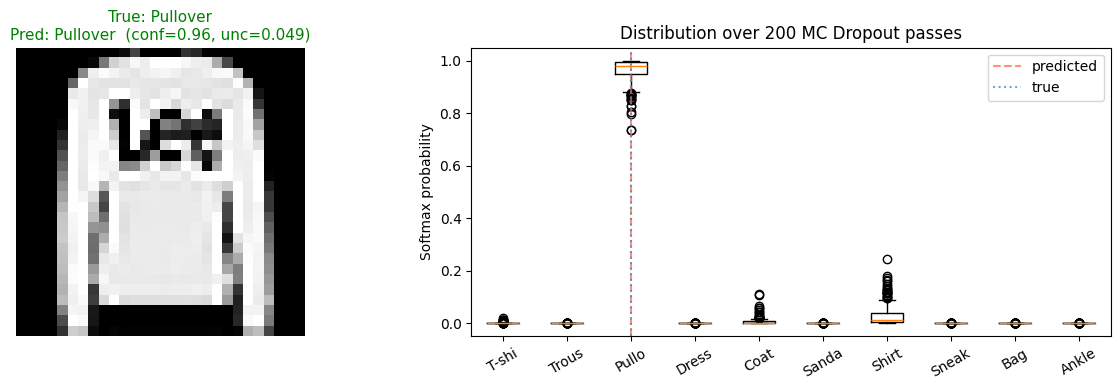

--- Most uncertain prediction (index 192) ---


/tmp/ipykernel_7635/1550296742.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=[c[:5] for c in CLASS_NAMES], vert=True)


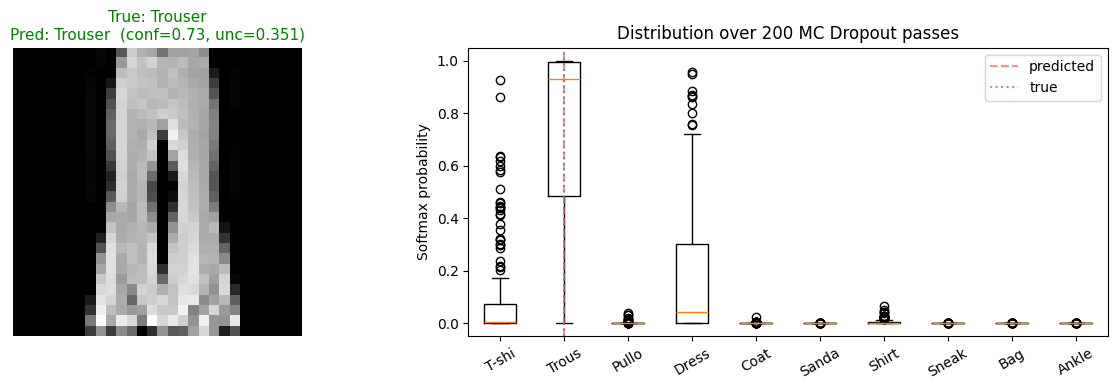

In [7]:
def plot_prediction_distribution(model, image, true_label, n_samples=200):
    """Show how softmax output varies across N MC Dropout passes for one image."""
    X = image[np.newaxis, ...]   # add batch dimension: (1, 28, 28)
    mean_p, std_p, all_p = mc_dropout_predict(model, X, n_samples=n_samples)

    pred_class  = mean_p[0].argmax()
    confidence  = mean_p[0].max()
    uncertainty = std_p[0].max()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: the image
    axes[0].imshow(image, cmap='gray')
    title_color = 'green' if pred_class == true_label else 'red'
    axes[0].set_title(
        f'True: {CLASS_NAMES[true_label]}\n'
        f'Pred: {CLASS_NAMES[pred_class]}  (conf={confidence:.2f}, unc={uncertainty:.3f})',
        color=title_color, fontsize=11
    )
    axes[0].axis('off')

    # Right: box-plot of softmax probability for each class across N passes
    # all_p shape: (n_samples, 1, 10) -> squeeze to (n_samples, 10)
    data = all_p[:, 0, :]   # shape: (n_samples, 10)
    axes[1].boxplot(data, labels=[c[:5] for c in CLASS_NAMES], vert=True)
    axes[1].axvline(pred_class + 1, color='tomato', linestyle='--', alpha=0.7, label='predicted')
    axes[1].axvline(true_label  + 1, color='steelblue', linestyle=':', alpha=0.7, label='true')
    axes[1].set_ylabel('Softmax probability')
    axes[1].set_title(f'Distribution over {n_samples} MC Dropout passes')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

# Show a confident correct prediction
print('--- Confident prediction ---')
plot_prediction_distribution(tf_model, X_test[1], y_test[1])

# Find an uncertain prediction to show contrast
mc_mean_all, mc_std_all, _ = mc_dropout_predict(tf_model, X_test[:200], n_samples=50)
uncertainty_scores = mc_std_all.max(axis=1)
most_uncertain_idx = uncertainty_scores.argmax()

print(f'--- Most uncertain prediction (index {most_uncertain_idx}) ---')
plot_prediction_distribution(tf_model, X_test[most_uncertain_idx], y_test[most_uncertain_idx])

### 6. Uncertainty vs Correctness

A well-calibrated uncertainty measure should correlate with errors:
the model should be most uncertain on the examples it gets wrong.
Here we check whether that holds.


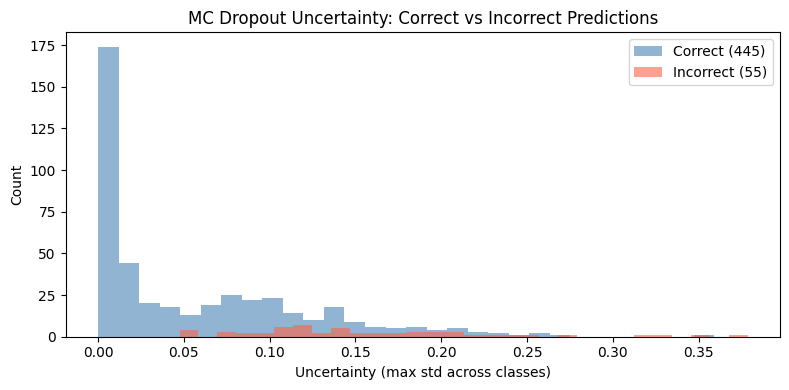

Mean uncertainty — correct predictions:   0.0553
Mean uncertainty — incorrect predictions: 0.1563

Incorrect predictions should show higher uncertainty — that is good calibration.


In [8]:
N_CHECK = 500
mc_mean_check, mc_std_check, _ = mc_dropout_predict(tf_model, X_test[:N_CHECK], n_samples=50)

preds_check   = mc_mean_check.argmax(axis=1)
correct_mask  = (preds_check == y_test[:N_CHECK])
unc_scores    = mc_std_check.max(axis=1)  # max std across classes as scalar uncertainty

unc_correct   = unc_scores[correct_mask]
unc_incorrect = unc_scores[~correct_mask]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(unc_correct,   bins=30, alpha=0.6, color='steelblue', label=f'Correct ({correct_mask.sum()})')
ax.hist(unc_incorrect, bins=30, alpha=0.6, color='tomato',    label=f'Incorrect ({(~correct_mask).sum()})')
ax.set_xlabel('Uncertainty (max std across classes)')
ax.set_ylabel('Count')
ax.set_title('MC Dropout Uncertainty: Correct vs Incorrect Predictions')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean uncertainty — correct predictions:   {unc_correct.mean():.4f}')
print(f'Mean uncertainty — incorrect predictions: {unc_incorrect.mean():.4f}')
print()
print('Incorrect predictions should show higher uncertainty — that is good calibration.')

### 7. Most Uncertain Predictions Gallery

Let us look at the images the model is most uncertain about.
These are almost always the genuinely ambiguous cases.


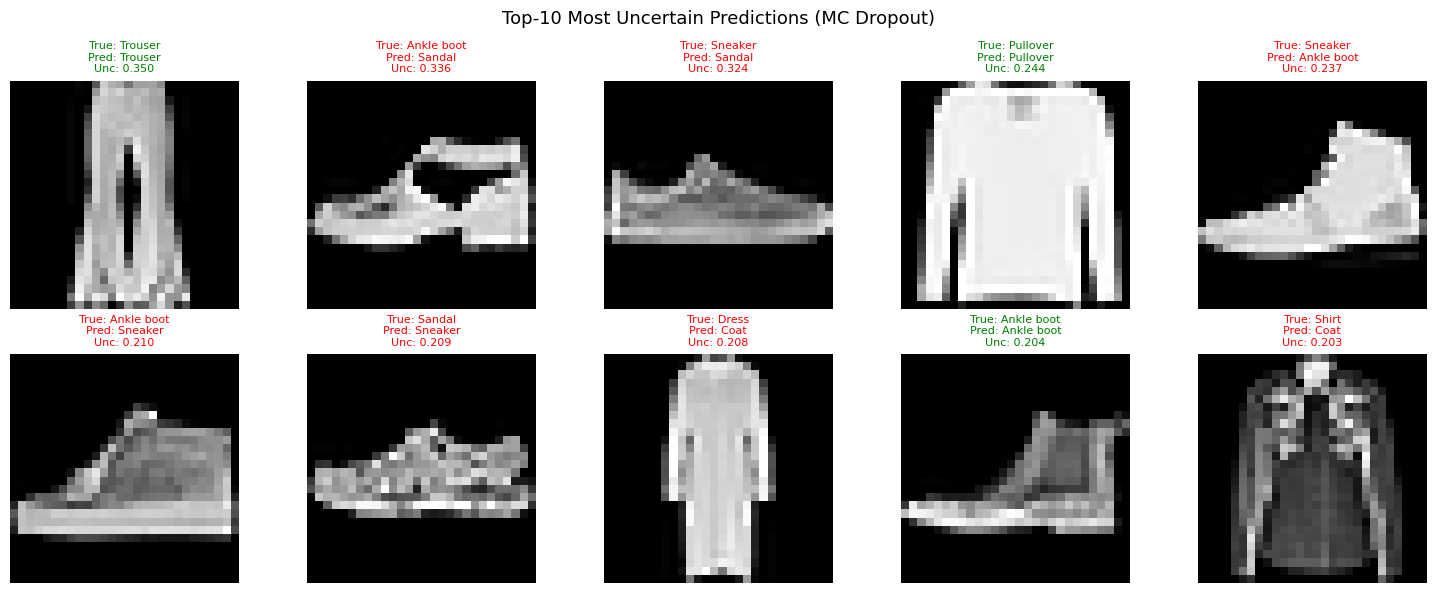

Red = wrong, Green = correct. High-uncertainty images tend to be visually ambiguous.


In [9]:
N_GALLERY = 200
mc_mean_gal, mc_std_gal, _ = mc_dropout_predict(tf_model, X_test[:N_GALLERY], n_samples=50)

unc_gal      = mc_std_gal.max(axis=1)
sorted_idx   = np.argsort(unc_gal)[::-1]   # highest uncertainty first

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Top-10 Most Uncertain Predictions (MC Dropout)', fontsize=13)

for ax, idx in zip(axes.flatten(), sorted_idx[:10]):
    ax.imshow(X_test[idx], cmap='gray')
    pred  = mc_mean_gal[idx].argmax()
    true  = y_test[idx]
    unc   = unc_gal[idx]
    color = 'green' if pred == true else 'red'
    ax.set_title(
        f'True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]}\nUnc: {unc:.3f}',
        color=color, fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Red = wrong, Green = correct. High-uncertainty images tend to be visually ambiguous.')

### 8. Effect of N on Uncertainty Estimate Stability

More passes = more stable uncertainty estimate, but slower inference.
We plot how accuracy and mean uncertainty change as N grows.


N=   1 | acc=0.8600 | mean_unc=0.0000 | time=0.03s
N=   5 | acc=0.8700 | mean_unc=0.0520 | time=0.12s
N=  10 | acc=0.8600 | mean_unc=0.0599 | time=0.27s
N=  20 | acc=0.8750 | mean_unc=0.0618 | time=0.49s
N=  50 | acc=0.8750 | mean_unc=0.0637 | time=1.10s
N= 100 | acc=0.8750 | mean_unc=0.0665 | time=2.11s


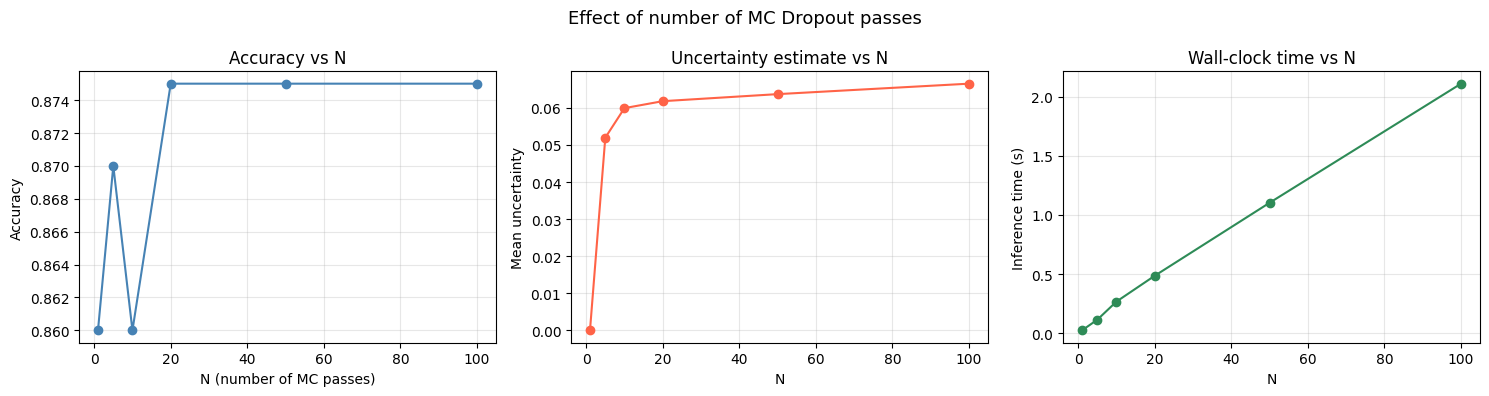

Accuracy stabilises quickly; N=30-50 is a practical sweet spot.


In [11]:
import time

N_EVAL2   = 200
n_samples_list = [1, 5, 10, 20, 50, 100]
accs, mean_uncs, times_taken = [], [], []

for n in n_samples_list:
    t0 = time.time()
    mc_m, mc_s, _ = mc_dropout_predict(tf_model, X_test[:N_EVAL2], n_samples=n)
    elapsed = time.time() - t0

    acc = (mc_m.argmax(axis=1) == y_test[:N_EVAL2]).mean()
    accs.append(acc)
    mean_uncs.append(mc_s.max(axis=1).mean())
    times_taken.append(elapsed)
    print(f'N={n:4d} | acc={acc:.4f} | mean_unc={mc_s.max(axis=1).mean():.4f} | time={elapsed:.2f}s')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(n_samples_list, accs, marker='o', color='steelblue')
axes[0].set_xlabel('N (number of MC passes)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs N')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_samples_list, mean_uncs, marker='o', color='tomato')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Mean uncertainty')
axes[1].set_title('Uncertainty estimate vs N')
axes[1].grid(True, alpha=0.3)

axes[2].plot(n_samples_list, times_taken, marker='o', color='seagreen')
axes[2].set_xlabel('N')
axes[2].set_ylabel('Inference time (s)')
axes[2].set_title('Wall-clock time vs N')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Effect of number of MC Dropout passes', fontsize=13)
plt.tight_layout()
plt.show()
print('Accuracy stabilises quickly; N=30-50 is a practical sweet spot.')

---
## Part B — PyTorch Implementation

The same MC Dropout idea in PyTorch. The key difference:
in PyTorch we call `model.train()` instead of passing `training=True`.


In [12]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_set, valid_set = torch.utils.data.random_split(
    train_full, [55000, 5000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

print('Data loaders ready.')

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.0MB/s]

Data loaders ready.


### PyTorch Model with Dropout


In [14]:
class DropoutNet(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(300, 200), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(200, 100), nn.ReLU(), nn.Dropout(dropout_rate * 0.7),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        return self.net(x)


def train_model_pt(model, epochs=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0

    for epoch in range(epochs):
        model.train()   # activates dropout
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()    # deactivates dropout for evaluation
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch).argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total   += y_batch.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d} | val_acc={val_acc:.4f}')

    print(f'Best val accuracy: {best_acc:.4f}')


pt_model = DropoutNet(dropout_rate=0.3).to(device)
print('Training PyTorch model...')
train_model_pt(pt_model, epochs=15)

Training PyTorch model...
Epoch  5 | val_acc=0.8698
Epoch 10 | val_acc=0.8764
Epoch 15 | val_acc=0.8836
Best val accuracy: 0.8836


### PyTorch MC Dropout Inference

In PyTorch the switch is `model.train()` (dropout ON) vs `model.eval()` (dropout OFF).
We call `model.train()` before our MC sampling loop, then restore `model.eval()` after.


In [15]:
def mc_dropout_predict_pt(model, X_tensor, n_samples=50):
    """
    PyTorch MC Dropout: call model.train() to keep dropout active,
    run N passes, then restore model.eval().

    Parameters
    ----------
    model    : trained nn.Module with nn.Dropout layers
    X_tensor : input tensor on the correct device
    n_samples: number of stochastic forward passes

    Returns
    -------
    mean_preds : np.array (batch, n_classes)
    std_preds  : np.array (batch, n_classes)
    """
    model.train()    # <-- keeps nn.Dropout active
    all_preds = []

    with torch.no_grad():
        for _ in range(n_samples):
            logits = model(X_tensor)              # raw logits
            probs  = torch.softmax(logits, dim=1) # convert to probabilities
            all_preds.append(probs.cpu().numpy())

    model.eval()     # <-- restore inference mode after sampling

    all_preds_np = np.stack(all_preds, axis=0)   # (N, batch, classes)
    return all_preds_np.mean(axis=0), all_preds_np.std(axis=0)


# Collect test tensors for first 500 samples
X_test_tensors, y_test_np = [], []
for X_batch, y_batch in test_loader:
    X_test_tensors.append(X_batch)
    y_test_np.append(y_batch.numpy())
    if sum(len(y) for y in y_test_np) >= 500:
        break

X_test_pt = torch.cat(X_test_tensors)[:500].to(device)
y_test_pt  = np.concatenate(y_test_np)[:500]

# Standard inference (dropout OFF)
pt_model.eval()
with torch.no_grad():
    std_probs_pt = torch.softmax(pt_model(X_test_pt), dim=1).cpu().numpy()
std_acc_pt = (std_probs_pt.argmax(axis=1) == y_test_pt).mean()

# MC Dropout (dropout ON)
mc_mean_pt, mc_std_pt = mc_dropout_predict_pt(pt_model, X_test_pt, n_samples=50)
mc_acc_pt = (mc_mean_pt.argmax(axis=1) == y_test_pt).mean()

print('PyTorch results on 500 test samples:')
print(f'  Standard inference (dropout OFF): {std_acc_pt:.4f}')
print(f'  MC Dropout N=50:                 {mc_acc_pt:.4f}')

PyTorch results on 500 test samples:
  Standard inference (dropout OFF): 0.8820
  MC Dropout N=50:                 0.8820


### Uncertainty vs Correctness — PyTorch


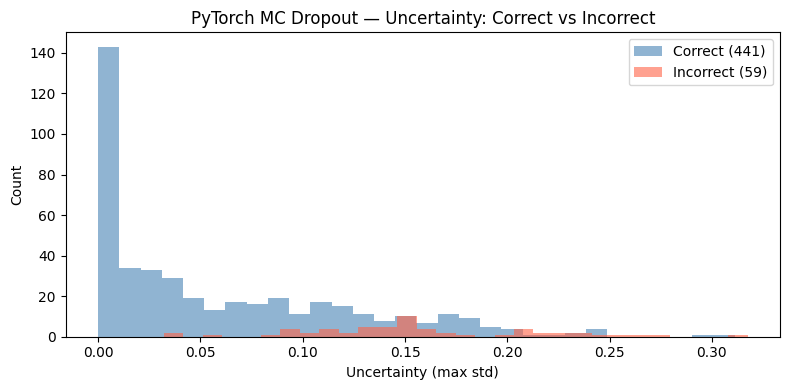

Mean uncertainty — correct:   0.0592
Mean uncertainty — incorrect: 0.1579


In [16]:
preds_pt      = mc_mean_pt.argmax(axis=1)
correct_pt    = (preds_pt == y_test_pt)
unc_pt        = mc_std_pt.max(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(unc_pt[correct_pt],  bins=30, alpha=0.6, color='steelblue', label=f'Correct ({correct_pt.sum()})')
ax.hist(unc_pt[~correct_pt], bins=30, alpha=0.6, color='tomato',    label=f'Incorrect ({(~correct_pt).sum()})')
ax.set_xlabel('Uncertainty (max std)')
ax.set_ylabel('Count')
ax.set_title('PyTorch MC Dropout — Uncertainty: Correct vs Incorrect')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean uncertainty — correct:   {unc_pt[correct_pt].mean():.4f}')
print(f'Mean uncertainty — incorrect: {unc_pt[~correct_pt].mean():.4f}')

---
## Summary

| Aspect | Standard Dropout | MC Dropout |
|---|---|---|
| Training | Active | Active |
| Inference | **OFF** (Keras default) | **ON** (forced via `training=True`) |
| Output | Single prediction | Distribution over N predictions |
| Uncertainty? | No | Yes — std of N passes |
| Accuracy | Baseline | Slightly higher (ensemble effect) |
| Speed | 1x | N times slower |
| Framework switch | `model.predict()` | TF: `model(X, training=True)` / PT: `model.train()` |

**Practical N values:**
- N=10 : fast, rough estimate
- N=30-50 : good balance of stability and speed (recommended)
- N=100+ : diminishing returns, use only when uncertainty precision matters

**Next: Notebook 04** — Weight Initializations (He, Glorot, LeCun, Orthogonal)
